# 20_异常值处理方法-均值填充

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这个小节，来详细的讲解一下异常值处理方法中的均值填充.

### 什么是异常值？为什么要处理？

**异常值（Outlier）**，就是指数据中那些**“特别大”或“特别小”**、**明显偏离其他数值**的数据点。

比如：一班学生的身高大多数是 160～180cm，突然有一个人身高 250cm，那就很可能是异常值。

异常值会带来的问题：

- 会**干扰分析**，让模型以为那是“正常情况”。
- 会**拉高或拉低均值**，让整个数据分析失真。

所以我们要对异常值进行处理。

### 什么是“均值填充”？

当我们发现某些值是异常的，想要处理它时，**“均值填充”就是用这个特征的平均值（Mean）来替换掉异常值**。

就好像你们班数学考试，有个同学突然得了 -50 分，老师觉得这是记错了，于是就把他的分数改成了全班的平均分。

**核心思想：**

- 用整个数据集的“代表性值”（均值）来替换“奇怪值”（异常值）。

### 举个简单例子

假设我们有一组学生的考试分数：`[80, 82, 85, 300, 84, 83]`

你一眼就能看出：

- 这组数据里，“300” 是个异常值（因为不可能考 300 分）。

我们可以：

1. 先算出去掉异常值以后的**平均分**

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
(80 + 82 + 85 + 84 + 83) / 5 = 82.8
```

1. 然后用这个平均值 82.8 来**替换掉 300**

最终得到填充后的数据：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
[80, 82, 85, 82.8, 84, 83]
```

这样，数据就“回归正常”了，不会影响后面的分析和模型训练。

### 算法流程

**步骤一：识别异常值**

选择一种异常值检测方法（如 Z-score 或 IQR），标记所有异常的值。

**步骤二：计算均值（剔除异常值）**

只用“正常数据”来计算平均值。


$$
\bar{x} = \frac{1}{m} \sum_{\text{正常值}} x_j
$$


**步骤三：替换异常值**

遍历原始数据集，对每个数据点：

- 如果是异常值 → 替换为 $\bar{x}$
- 如果不是异常值 → 保留原值

**步骤四：输出新的数据集**

新的数据集就没有“极端值”干扰，变得更平稳、更适合建模和分析。

**但注意：** 它可能会让数据的方差变小，信息量减少，所以适合于数据量较小、对方差不敏感的情况。

## 完整案例

我们使用一个模拟的「城市空气质量监测数据集」，其中包含多个城市的 PM2.5 浓度数据。由于某些设备故障、数据上传错误或极端天气，可能会出现**异常的 PM2.5 数值**（如特别高或负数），这会影响后续的分析。

目标是：使用「均值填充法」检测并处理 PM2.5 的异常值，使得数据更加稳定，适用于后续建模。

### 加载与可视化数据

模拟一组数据，其中故意加入了一些异常值（比如 -50、999）。

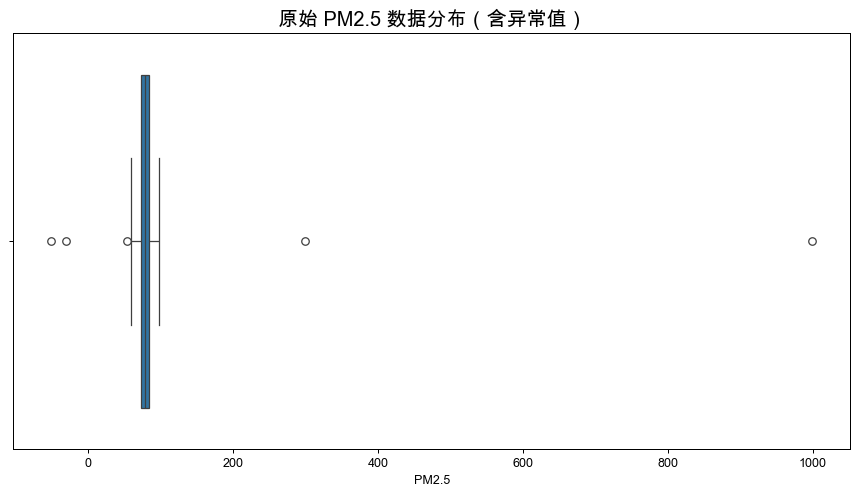

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 模拟数据
np.random.seed(42)
normal_data = np.random.normal(loc=80, scale=10, size=100)   # 正常的 PM2.5 数据
outliers = np.array([-50, 300, 999, -30])                     # 加入异常值
pm25_data = np.concatenate([normal_data, outliers])
df = pd.DataFrame({'PM2.5': pm25_data})

# 原始数据可视化
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='PM2.5')
plt.title('原始 PM2.5 数据分布（含异常值）', fontsize=16)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_011.png)

### 异常值检测（使用 IQR 方法）

我们采用**四分位距法（IQR）**来识别异常值。

In [3]:
# 计算 IQR 边界
Q1 = df['PM2.5'].quantile(0.25)
Q3 = df['PM2.5'].quantile(0.75)
IQR = Q3 - Q1

# 设置上下限
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 标记异常值
df['is_outlier'] = (df['PM2.5'] < lower_bound) | (df['PM2.5'] > upper_bound)

print("异常值列表：")
print(df[df['is_outlier']])

异常值列表：
          PM2.5  is_outlier
74    53.802549        True
100  -50.000000        True
101  300.000000        True
102  999.000000        True
103  -30.000000        True


### 均值填充异常值

我们计算“非异常值”的均值，并用它来替换异常值。

In [4]:
# 提取非异常数据
normal_values = df.loc[~df['is_outlier'], 'PM2.5']
mean_value = normal_values.mean()

# 创建一个新的列，填充后的数据
df['PM2.5_filled'] = df.apply(
    lambda row: mean_value if row['is_outlier'] else row['PM2.5'], axis=1
)

### 对比分析（填充前后）

下面我们绘制两个对比图，观察填充前后数据的变化：

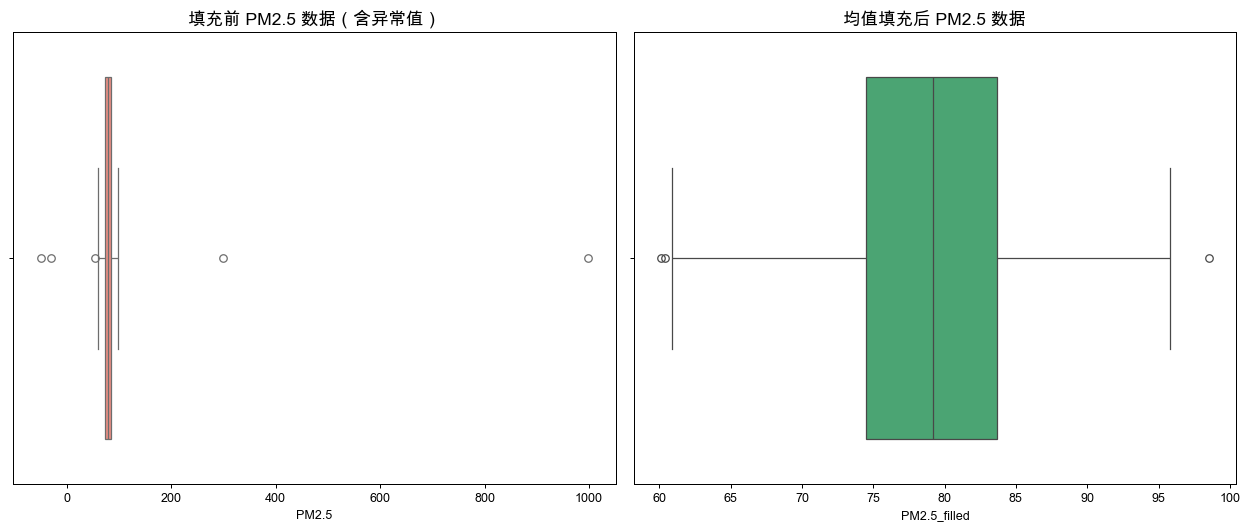

In [5]:
# 原始数据 vs 均值填充数据
plt.figure(figsize=(14, 6))

# 原始数据
plt.subplot(1, 2, 1)
sns.boxplot(x=df['PM2.5'], color="salmon")
plt.title("填充前 PM2.5 数据（含异常值）", fontsize=14)

# 均值填充后的数据
plt.subplot(1, 2, 2)
sns.boxplot(x=df['PM2.5_filled'], color="mediumseagreen")
plt.title("均值填充后 PM2.5 数据", fontsize=14)

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_012.png)

**数据生成与可视化**：

我们使用 `numpy.random.normal()` 来生成符合正态分布的 PM2.5 数据（平均为 80，标准差为 10），然后加入 4 个异常值：

- `-50`, `-30`（可能是设备错误）
- `300`, `999`（可能是极端污染或输入错误）

可视化使用 seaborn 的 `boxplot`，非常适合观察异常值。

**异常值检测（IQR法）**：

**四分位距法（Interquartile Range, IQR）**是一种稳健的统计方法，它不受极端值影响，适合识别异常值。

计算方式如下：


$$
\text{IQR} = Q3 - Q1
$$


$$
\text{下界} = Q1 - 1.5 \cdot \text{IQR}
$$


$$
\text{上界} = Q3 + 1.5 \cdot \text{IQR}
$$


凡是小于下界或大于上界的值都被认为是异常。

**均值填充**：

使用非异常值计算均值：

In [6]:
mean_value = normal_values.mean()

然后通过 `apply()` 函数实现条件替换，逻辑如下：

- 如果当前行为异常值 → 替换为均值
- 否则保留原值

这一步非常关键，体现了“均值填充”的核心思想。

**可视化对比**：

我们再次使用 boxplot 来对比处理前后的数据分布，观察：

- 异常值是否被清除？
- 数据分布是否更加集中？

### 均值填充法的优点和缺点

**优点**：

1. **简单易用**：算法直观、计算量小，非常适合初学者和快速预处理。
2. **保持样本数量不变**：不会像“删除法”那样直接丢弃数据，避免了信息损失。
3. **适用于偏态较小的数据**：如果数据总体是“正态分布”或“近似正态”，均值是非常好的代表值。
4. **易于集成到模型管道中**：尤其适合在训练前统一填补空缺或异常项。

**缺点**：

1. **可能扭曲数据分布**：对偏态数据或多峰数据，均值未必是好的代表，可能会降低模型性能。
2. **降低方差，增加相似性**：用一个固定值填充会导致数据变得“太一致”，让模型捕捉不到原始差异。
3. **忽略了数据生成机制**：如果异常值有意义（如突发污染事件），均值填充可能掩盖了重要信息。
4. **对高度非线性模型不友好**：在深度学习或时间序列中，这种简单填充可能带来信息偏移。

### 适合使用均值填充的场景

均值填充不是“万能药”，但它适合以下几种情形：

- **小规模异常**：异常值占比很少，不是系统性错误。
- **数据近似正态分布**：中位数与均值差不多的情况。
- **模型不太依赖极端波动**：如线性回归、决策树初级模型。
- **任务对数据真实性要求不高**：如简单可视化、教学演示或快速原型。

## 总结

虽然均值填充方法简单，但在实际项目中仍有其一定的价值，特别是在模型初期开发或需要快速清洗数据的阶段，是一种“快速、安全”的手段。不过，对于更精细的任务，大家要结合其他方法（如插值、模型预测填充）一起使用。